# Week 5 Healthcare Class Demo 1

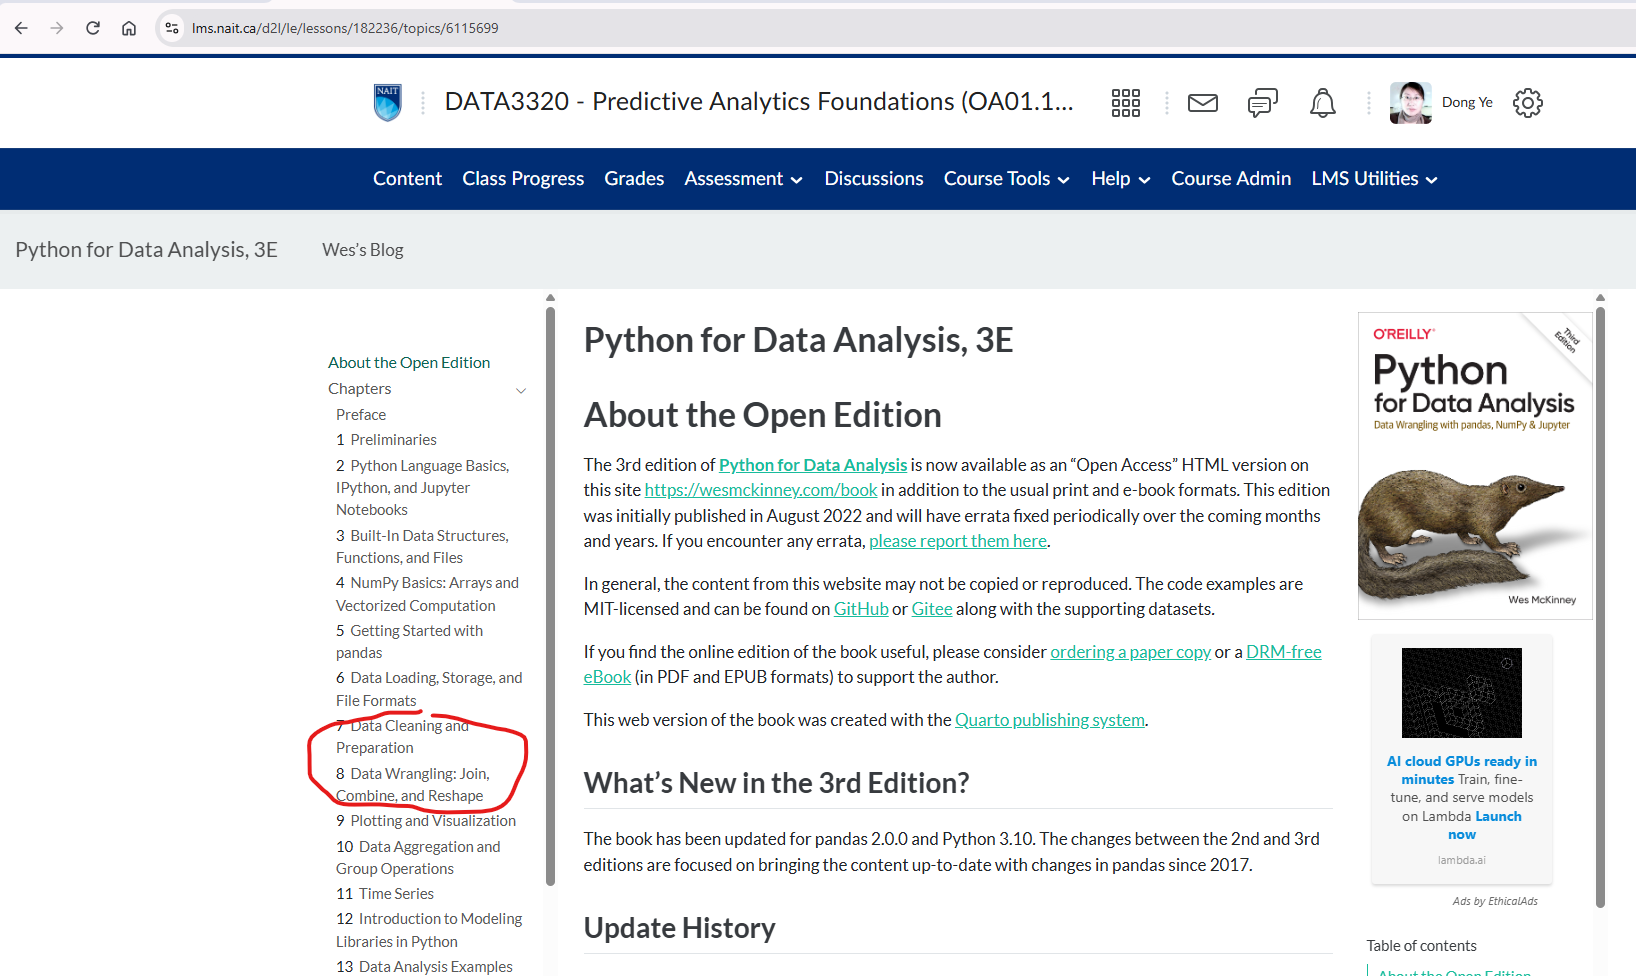

📖 **Reference Reading:** [Python for Data Analysis (Chapter 7 & 8)](https://lms.nait.ca/d2l/le/lessons/182236/topics/6115699)

In [12]:
from IPython.display import Image, display, Markdown

display(Image("Chapter7-8_data_cleaning.png", width=800))

display(Markdown(
    "📖 **Reference Reading:** "
    "[Python for Data Analysis (Chapter 7 & 8)]"
    "(https://lms.nait.ca/d2l/le/lessons/182236/topics/6115699)"
))


## From Raw Data to a Clean Initial Business Report

 
**Dataset:** Healthcare encounter data loaded directly from GitHub  


## Business case: AlbertaCare Health Network

AlbertaCare Health Network operates several healthcare facilities. Management wants to improve patient access, control operating costs, and understand differences among facilities, regions, and service lines.

You are a **junior data analyst**. Your responsibility is to use simple pandas data-wrangling steps to turn encounter data into useful business information.

> This is a classroom scenario created for learning. All conclusions must be based on the supplied dataset.

## Learning outcomes
- Load a CSV file from GitHub into a pandas DataFrame.
- inspect rows, columns, data types, and basic summary information.
- identify missing values and duplicated rows.
- filter, sort, and create simple calculated or grouped columns.
- prepare a clean dataset for management analysis.
  


## 110-minute roadmap
| Time | Level | Focus |
|---:|---|---|
| 0-10 | Orientation | Business case and analytical questions |
| 10-25 | Beginning | Load and inspect the data |
| 25-40 | Beginning | Select columns and count categories |
| 40-55 | Developing | Find missing values and duplicates |
| 55-70 | Developing | Filter and sort records |
| 70-85 | Developing | Create age groups and simple flags |
| 85-100 | Challenging | Group and summarize operational data |
| 100-110 | Application | Mini business report and exit check |

## Learning strategy

Every section follows the same sequence:

1. **Business question**: What does management need to know?
2. **Wrangling strategy**: What data operation will answer the question?
3. **Key code**: Which simple pandas command will be used?
4. **Interpretation**: What does the output mean?
5. **Your turn**: Students apply the same idea to a new question.

Run the cells from top to bottom. Attempt each student activity before reading the solution cell.


## 1. Management request and analytical plan, 0-10 minutes

### Business problem
Before management uses the encounter data, the analytics team must determine whether the file is understandable and usable. Management asks:

- How many encounter records are available?
- Which facilities and services appear in the data?
- Are important values missing?
- Are any rows duplicated?
- Which visit types and age groups appear most often?

### Strategy
Begin with broad inspection. Then move gradually to cleaning, filtering, and simple summaries. Do not change values until the problem has been identified.

### Check-in
What could happen if management makes a decision before missing values and duplicates are checked?

## 2. Beginning: Load the data, 10-15 minutes

### Business question
Did the healthcare file load correctly?

### Key code
- `pd.read_csv()` reads a CSV file into a DataFrame.
- `head()` displays the first five rows.

### Strategy
Load the live file from GitHub and inspect a small sample. The DataFrame is named `df` to keep later code simple.

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

DATA_URL = "https://raw.githubusercontent.com/Dong2Yo/PredcitiveAnalysis_BusinessProfessional/refs/heads/main/data/Healthcare.csv"
pd.set_option("display.max_columns", 25)


In [19]:
import pandas as pd
df1 = pd.read_csv(
    "https://raw.githubusercontent.com/Dong2Yo/PredcitiveAnalysis_BusinessProfessional/refs/heads/main/data/Healthcare.csv"
)

In [18]:
df = pd.read_csv(DATA_URL)
df.head()

,Encounter_ID,Encounter_Date,Facility,Region,Service_Line,Patient_ID,Patient_Age,Patient_Sex,Provider_ID,Visit_Status,Wait_Time_Min,Visit_Duration_Min,Cost_CAD,Payer_Type,Outcome_Status,Satisfaction_Score
0,E0001,2026-01-07,Northside Medical Centre,North,Diabetes Education,PT0014,38.0,X,P008,Completed,23.6,41.2,234.77,Employer Plan,Improved,4.0
1,E0002,2026-01-09,River Valley Clinic,Central,Cardiology,PT0027,73.0,F,P015,Completed,38.6,32.2,320.73,Private,Improved,5.0
2,E0003,2026-01-11,Westgate Health Hub,West,Sleep Clinic,PT0040,63.0,F,P004,Completed,48.7,62.4,371.63,Public,Stable,4.0
3,E0004,2026-01-13,South Edmonton Care Centre,South,Respiratory,PT0053,18.0,X,P011,Completed,47.3,50.3,292.09,Employer Plan,Follow-up Required,4.0
4,E0005,2026-01-15,Northside Medical Centre,North,Primary Care,PT0066,62.0,X,P018,Completed,22.1,51.6,153.51,Private,Improved,5.0


## 3. Beginning: Understand the table, 15-25 minutes

### Business question
How large is the file, what columns are available, and what types of values are stored?

### Key code
- `shape` returns `(rows, columns)`.
- `columns` lists column names.
- `info()` displays data types and non-null counts.
- `describe()` summarizes numeric columns.

### Strategy
Use several small inspection commands. Each command answers a different question.

In [20]:
print("Rows and columns:", df.shape)
print()
print("Column names:")
print(df.columns.tolist())
print()
print("Data information:")
df.info()

Rows and columns: (180, 16)

Column names:
['Encounter_ID', 'Encounter_Date', 'Facility', 'Region', 'Service_Line', 'Patient_ID', 'Patient_Age', 'Patient_Sex', 'Provider_ID', 'Visit_Status', 'Wait_Time_Min', 'Visit_Duration_Min', 'Cost_CAD', 'Payer_Type', 'Outcome_Status', 'Satisfaction_Score']

Data information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Encounter_ID        180 non-null    object 
 1   Encounter_Date      180 non-null    object 
 2   Facility            180 non-null    object 
 3   Region              180 non-null    object 
 4   Service_Line        180 non-null    object 
 5   Patient_ID          180 non-null    object 
 6   Patient_Age         167 non-null    float64
 7   Patient_Sex         180 non-null    object 
 8   Provider_ID         176 non-null    object 
 9   Visit_Status        180 non-null    

In [22]:
df.describe()

,Patient_Age,Wait_Time_Min,Visit_Duration_Min,Cost_CAD,Satisfaction_Score
count,167.000000,180.000000,180.000000,180.000000,141.000000
mean,52.730539,36.302778,42.422778,262.989944,4.312057
std,19.024536,13.254081,14.337164,106.941311,0.698312
min,18.000000,4.000000,10.000000,60.000000,3.000000
25%,38.000000,25.875000,32.275000,175.147500,4.000000
50%,53.000000,35.550000,42.600000,274.915000,4.000000
75%,68.000000,46.050000,51.125000,351.702500,5.000000
max,85.000000,72.000000,83.400000,500.380000,5.000000


### Check-in 1
Discuss with a partner:
1. What does one row represent?
2. Which column uniquely identifies an encounter?
3. Which columns contain numbers?
4. Which columns could support management decisions?

## Missing Values vs. Invalid Data Values

A **missing value** means that no usable value was recorded. Pandas normally represents missing values as `NaN`, `None`, or `pd.NA`.

An **invalid data value** is a recorded value that does not follow the expected rules for a column. For example:

- `?` in an occupation column
- `-5` in an age column
- `Maybe` in a column that should contain only `Yes` or `No`
- `abc` in a numeric column

The `?` symbol is technically stored as a text value. Therefore, Pandas does not automatically count it as missing:

- `income.info()` may report no null values.
- `income.isnull().sum()` may report zero.
- The `?` values are still unusable and must be identified during data validation.

In this dataset, `?` represents unavailable information. We will treat it as an unknown category by replacing it with `Unknown`.

> **Key idea:** A value can be non-null but still be invalid or unusable.

In [24]:
import pandas as pd
income = pd.read_csv('https://raw.githubusercontent.com/Dong2Yo/PredcitiveAnalysis_BusinessProfessional/refs/heads/main/data/adult_income.csv')
income.head(9)

,Age,Work Class,fnlwgt,Education,Education-num,Marital-Status,Occupation,Relationship,Race,Sex,Capital-gain,Capital-loss,Hours-per-week,Native-country,Income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K


In [26]:
income.shape

(32561, 15)

In [28]:
income.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Age             32561 non-null  int64 
 1   Work Class      32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   Education       32561 non-null  object
 4   Education-num   32561 non-null  int64 
 5   Marital-Status  32561 non-null  object
 6   Occupation      32561 non-null  object
 7   Relationship    32561 non-null  object
 8   Race            32561 non-null  object
 9   Sex             32561 non-null  object
 10  Capital-gain    32561 non-null  int64 
 11  Capital-loss    32561 non-null  int64 
 12  Hours-per-week  32561 non-null  int64 
 13  Native-country  32561 non-null  object
 14  Income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [34]:
# Find rows containing ? after removing spaces
question_rows = income.astype(str).apply(
    lambda col: col.str.strip().eq('?')
).any(axis=1)

income[question_rows].head(10)

,Age,Work Class,fnlwgt,Education,Education-num,Marital-Status,Occupation,Relationship,Race,Sex,Capital-gain,Capital-loss,Hours-per-week,Native-country,Income
14,40,Private,121772,Assoc-voc,11,Married-civ-spouse,Craft-repair,Husband,Asian-Pac-Islander,Male,0,0,40,?,>50K
27,54,?,180211,Some-college,10,Married-civ-spouse,?,Husband,Asian-Pac-Islander,Male,0,0,60,South,>50K
38,31,Private,84154,Some-college,10,Married-civ-spouse,Sales,Husband,White,Male,0,0,38,?,>50K
51,18,Private,226956,HS-grad,9,Never-married,Other-service,Own-child,White,Female,0,0,30,?,<=50K
61,32,?,293936,7th-8th,4,Married-spouse-absent,?,Not-in-family,White,Male,0,0,40,?,<=50K
69,25,?,200681,Some-college,10,Never-married,?,Own-child,White,Male,0,0,40,United-States,<=50K
77,67,?,212759,10th,6,Married-civ-spouse,?,Husband,White,Male,0,0,2,United-States,<=50K
93,30,Private,117747,HS-grad,9,Married-civ-spouse,Sales,Wife,Asian-Pac-Islander,Female,0,1573,35,?,<=50K
106,17,?,304873,10th,6,Never-married,?,Own-child,White,Female,34095,0,32,United-States,<=50K
128,35,?,129305,HS-grad,9,Married-civ-spouse,?,Husband,White,Male,0,0,40,United-States,<=50K


In [38]:
# Pandas sees no missing values
print(income.isnull().sum().sum())



0


In [40]:
# But let's look for invalid placeholder values
print((income.astype(str).apply(lambda col: col.str.strip()) == '?').sum())

Age                  0
Work Class        1836
fnlwgt               0
Education            0
Education-num        0
Marital-Status       0
Occupation        1843
Relationship         0
Race                 0
Sex                  0
Capital-gain         0
Capital-loss         0
Hours-per-week       0
Native-country     583
Income               0
dtype: int64


## 4. Beginning: Select columns and count categories, 25-40 minutes

### Business question
Which regions, service lines, and visit statuses occur most often?

### Key code
- `df["Column"]` selects one column.
- `df[["A", "B"]]` selects several columns.
- `value_counts()` counts each category.
- `nunique()` counts distinct values.

### Strategy
Start with one column at a time. Counts help management understand volume and distribution.

In [24]:
df[["Encounter_ID", "Facility", "Region", "Service_Line", "Visit_Status"]].head()

,Encounter_ID,Facility,Region,Service_Line,Visit_Status
0,E0001,Northside Medical Centre,North,Diabetes Education,Completed
1,E0002,River Valley Clinic,Central,Cardiology,Completed
2,E0003,Westgate Health Hub,West,Sleep Clinic,Completed
3,E0004,South Edmonton Care Centre,South,Respiratory,Completed
4,E0005,Northside Medical Centre,North,Primary Care,Completed


In [26]:
print("Number of facilities:", df["Facility"].nunique())
print("Number of service lines:", df["Service_Line"].nunique())
print()
print("Encounters by region:")
print(df["Region"].value_counts())
print()
print("Encounters by visit status:")
print(df["Visit_Status"].value_counts())

Number of facilities: 4
Number of service lines: 5

Encounters by region:
Region
North      45
Central    45
West       45
South      45
Name: count, dtype: int64

Encounters by visit status:
Visit_Status
Completed    146
Cancelled     26
No Show        8
Name: count, dtype: int64


### YOUR TURN 1
1. Count encounters by `Service_Line`.
2. Count encounters by `Payer_Type`.
3. Find the number of unique patients.
4. Write one sentence describing the largest category in either count.

In [ ]:
# Student activity
# Add your code below.


<details><summary><strong>Solution: YOUR TURN 1</strong></summary>Open after attempting the activity.</details>

In [28]:
print(df["Service_Line"].value_counts())
print(df["Payer_Type"].value_counts())
print("Unique patients:", df["Patient_ID"].nunique())

Service_Line
Diabetes Education    36
Cardiology            36
Sleep Clinic          36
Respiratory           36
Primary Care          36
Name: count, dtype: int64
Payer_Type
Employer Plan    60
Private          60
Public           60
Name: count, dtype: int64
Unique patients: 125


## 5. Developing: Missing values and duplicates, 40-55 minutes

### Business question
Can every record be used in every analysis?

### Key code
- `isnull()` marks missing values as `True`.
- `isnull().sum()` counts missing values by column.
- `duplicated().sum()` counts duplicated rows.
- `drop_duplicates()` removes exactly duplicated rows.

### Strategy
First count missing values. Then inspect affected rows. A missing satisfaction score may be reasonable for a cancelled or no-show visit, while a missing provider ID may require investigation.

In [30]:
df.isnull().sum()

Encounter_ID           0
Encounter_Date         0
Facility               0
Region                 0
Service_Line           0
Patient_ID             0
Patient_Age           13
Patient_Sex            0
Provider_ID            4
Visit_Status           0
Wait_Time_Min          0
Visit_Duration_Min     0
Cost_CAD               0
Payer_Type             0
Outcome_Status         0
Satisfaction_Score    39
dtype: int64

In [32]:
df[df["Patient_Age"].isnull()].head()

,Encounter_ID,Encounter_Date,Facility,Region,Service_Line,Patient_ID,Patient_Age,Patient_Sex,Provider_ID,Visit_Status,Wait_Time_Min,Visit_Duration_Min,Cost_CAD,Payer_Type,Outcome_Status,Satisfaction_Score
8,E0009,2026-01-23,Northside Medical Centre,North,Diabetes Education,PT0118,NaN,M,P010,Completed,32.8,27.3,187.33,Public,Stable,4.0
23,E0024,2026-02-22,South Edmonton Care Centre,South,Sleep Clinic,PT0063,NaN,M,P007,Completed,46.2,80.0,273.05,Public,Improved,4.0
32,E0033,2026-03-12,Northside Medical Centre,North,Respiratory,PT0055,NaN,M,P016,Completed,48.8,47.2,222.17,Public,Improved,3.0
38,E0039,2026-03-24,Westgate Health Hub,West,Cardiology,PT0008,NaN,F,P004,Completed,34.3,44.3,367.60,Public,Stable,4.0
43,E0044,2026-04-03,South Edmonton Care Centre,South,Cardiology,PT0073,NaN,M,P003,Completed,32.8,30.0,351.33,Private,Improved,5.0


In [34]:
df[df["Satisfaction_Score"].isnull()][
    ["Encounter_ID", "Visit_Status", "Satisfaction_Score"]
].head(10)

,Encounter_ID,Visit_Status,Satisfaction_Score
7,E0008,Cancelled,NaN
15,E0016,No Show,NaN
19,E0020,Cancelled,NaN
22,E0023,Completed,NaN
26,E0027,Cancelled,NaN
27,E0028,Cancelled,NaN
29,E0030,No Show,NaN
30,E0031,Cancelled,NaN
40,E0041,Cancelled,NaN
45,E0046,Completed,NaN


In [36]:
print("Duplicated rows:", df.duplicated().sum())

clean_df = df.drop_duplicates()
print("Original rows:", len(df))
print("Rows after duplicate removal:", len(clean_df))

Duplicated rows: 0
Original rows: 180
Rows after duplicate removal: 180


### Check-in 2
Should missing satisfaction scores be replaced with zero?

**Suggested interpretation:** No. A score of zero would be a real value, while a blank may mean that no survey response was available. Keep the missing value unless a justified business rule is provided.

## 6. Developing: Filter and sort, 55-70 minutes

### Business question
Which encounters require closer attention?

### Key code
- A condition inside brackets filters rows.
- `&` combines two conditions and means **and**.
- `sort_values()` arranges records by a chosen column.

### Strategy
Begin with one condition. Then combine two conditions. Finally, sort the result to show the most important records first.

In [38]:
completed_visits = clean_df[clean_df["Visit_Status"] == "Completed"]
completed_visits.head()

,Encounter_ID,Encounter_Date,Facility,Region,Service_Line,Patient_ID,Patient_Age,Patient_Sex,Provider_ID,Visit_Status,Wait_Time_Min,Visit_Duration_Min,Cost_CAD,Payer_Type,Outcome_Status,Satisfaction_Score
0,E0001,2026-01-07,Northside Medical Centre,North,Diabetes Education,PT0014,38.0,X,P008,Completed,23.6,41.2,234.77,Employer Plan,Improved,4.0
1,E0002,2026-01-09,River Valley Clinic,Central,Cardiology,PT0027,73.0,F,P015,Completed,38.6,32.2,320.73,Private,Improved,5.0
2,E0003,2026-01-11,Westgate Health Hub,West,Sleep Clinic,PT0040,63.0,F,P004,Completed,48.7,62.4,371.63,Public,Stable,4.0
3,E0004,2026-01-13,South Edmonton Care Centre,South,Respiratory,PT0053,18.0,X,P011,Completed,47.3,50.3,292.09,Employer Plan,Follow-up Required,4.0
4,E0005,2026-01-15,Northside Medical Centre,North,Primary Care,PT0066,62.0,X,P018,Completed,22.1,51.6,153.51,Private,Improved,5.0


In [40]:
long_waits = clean_df[clean_df["Wait_Time_Min"] > 45]
long_waits[["Encounter_ID", "Facility", "Service_Line", "Wait_Time_Min"]].head()

,Encounter_ID,Facility,Service_Line,Wait_Time_Min
2,E0003,Westgate Health Hub,Sleep Clinic,48.7
3,E0004,South Edmonton Care Centre,Respiratory,47.3
7,E0008,South Edmonton Care Centre,Sleep Clinic,55.9
10,E0011,Westgate Health Hub,Sleep Clinic,53.6
17,E0018,River Valley Clinic,Cardiology,56.5


In [42]:
long_completed_waits = clean_df[
    (clean_df["Visit_Status"] == "Completed") &
    (clean_df["Wait_Time_Min"] > 45)
]

long_completed_waits.sort_values("Wait_Time_Min", ascending=False).head(10)

,Encounter_ID,Encounter_Date,Facility,Region,Service_Line,Patient_ID,Patient_Age,Patient_Sex,Provider_ID,Visit_Status,Wait_Time_Min,Visit_Duration_Min,Cost_CAD,Payer_Type,Outcome_Status,Satisfaction_Score
52,E0053,2026-04-21,Northside Medical Centre,North,Sleep Clinic,PT0065,46.0,M,P012,Completed,72.0,78.5,297.20,Private,Improved,5.0
100,E0101,2026-02-26,Northside Medical Centre,North,Sleep Clinic,PT0064,56.0,F,P006,Completed,64.3,56.9,412.52,Private,Improved,4.0
39,E0040,2026-03-26,South Edmonton Care Centre,South,Sleep Clinic,PT0021,63.0,F,P011,Completed,63.9,54.9,379.77,Employer Plan,Improved,4.0
133,E0134,2026-05-03,River Valley Clinic,Central,Cardiology,PT0118,79.0,X,P003,Completed,62.7,33.7,382.23,Private,Stable,5.0
121,E0122,2026-04-09,River Valley Clinic,Central,Sleep Clinic,PT0087,50.0,F,P009,Completed,61.5,72.3,356.94,Private,Improved,4.0
108,E0109,2026-03-14,Northside Medical Centre,North,Sleep Clinic,PT0043,48.0,F,P008,Completed,61.2,48.3,417.96,Employer Plan,Stable,5.0
144,E0145,2026-05-25,Northside Medical Centre,North,Cardiology,PT0011,40.0,X,P008,Completed,60.6,51.6,500.38,Employer Plan,Stable,4.0
142,E0143,2026-05-21,Westgate Health Hub,West,Sleep Clinic,PT0110,31.0,M,P012,Completed,59.1,47.6,317.37,Private,Improved,4.0
149,E0150,2026-01-05,River Valley Clinic,Central,Cardiology,PT0076,64.0,X,P007,Completed,57.6,43.9,414.26,Public,Stable,5.0
17,E0018,2026-02-10,River Valley Clinic,Central,Cardiology,PT0110,31.0,F,P001,Completed,56.5,25.5,353.33,Public,Improved,5.0


### YOUR TURN 2
1. Filter cancelled visits.
2. Filter Cardiology visits.
3. Find completed Cardiology visits.
4. Sort the result from highest to lowest `Cost_CAD`.

In [ ]:
# Student activity


<details><summary><strong>Solution: YOUR TURN 2</strong></summary></details>

In [44]:
cancelled = clean_df[clean_df["Visit_Status"] == "Cancelled"]
cardiology = clean_df[clean_df["Service_Line"] == "Cardiology"]
completed_cardiology = clean_df[
    (clean_df["Visit_Status"] == "Completed") &
    (clean_df["Service_Line"] == "Cardiology")
]
completed_cardiology.sort_values("Cost_CAD", ascending=False).head()

,Encounter_ID,Encounter_Date,Facility,Region,Service_Line,Patient_ID,Patient_Age,Patient_Sex,Provider_ID,Visit_Status,Wait_Time_Min,Visit_Duration_Min,Cost_CAD,Payer_Type,Outcome_Status,Satisfaction_Score
144,E0145,2026-05-25,Northside Medical Centre,North,Cardiology,PT0011,40.0,X,P008,Completed,60.6,51.6,500.38,Employer Plan,Stable,4.0
178,E0179,2026-03-04,Westgate Health Hub,West,Cardiology,PT0078,73.0,X,P012,Completed,31.1,29.9,453.93,Private,Improved,5.0
157,E0158,2026-01-21,River Valley Clinic,Central,Cardiology,PT0055,40.0,X,P009,Completed,45.8,28.3,447.08,Private,Stable,5.0
62,E0063,2026-05-11,Westgate Health Hub,West,Cardiology,PT0070,53.0,X,P010,Completed,29.0,42.2,442.34,Public,Stable,4.0
99,E0100,2026-02-24,South Edmonton Care Centre,South,Cardiology,PT0051,40.0,M,P017,Completed,28.8,28.3,434.87,Employer Plan,Improved,5.0


## 7. Developing: Create useful columns, 70-85 minutes

### Business question
Can raw values be organized into categories that are easier for management to discuss?

### Key code
- `fillna()` replaces missing values.
- `pd.cut()` places numeric values into ranges.
- A Boolean comparison creates `True` and `False` values.

### Strategy
Create a new working copy. Fill missing age with the median only for this classroom exercise, create age groups, and flag waits longer than 45 minutes. Preserve the original `df`.

In [46]:
work_df = clean_df.copy()

median_age = work_df["Patient_Age"].median()
work_df["Patient_Age"] = work_df["Patient_Age"].fillna(median_age)

print("Median age used:", median_age)
print("Missing ages remaining:", work_df["Patient_Age"].isnull().sum())

Median age used: 53.0
Missing ages remaining: 0


In [48]:
work_df["Age_Group"] = pd.cut(
    work_df["Patient_Age"],
    bins=[0, 17, 34, 49, 64, 100],
    labels=["0-17", "18-34", "35-49", "50-64", "65+"]
)

work_df["Long_Wait"] = work_df["Wait_Time_Min"] > 45
work_df[["Patient_Age", "Age_Group", "Wait_Time_Min", "Long_Wait"]].head()

,Patient_Age,Age_Group,Wait_Time_Min,Long_Wait
0,38.0,35-49,23.6,False
1,73.0,65+,38.6,False
2,63.0,50-64,48.7,True
3,18.0,18-34,47.3,True
4,62.0,50-64,22.1,False


## 8. Challenging: Group and summarize, 85-100 minutes

### Business question
Which regions and service lines show the greatest operational pressure?

### Key code
- `groupby()` creates groups.
- `mean()` calculates an average.
- `count()` counts non-missing values.
- `agg()` calculates several summaries at once.

### Strategy
Start with one grouping and one measure. Then create a small management summary with several measures.

In [51]:
work_df.groupby("Region")["Wait_Time_Min"].mean().round(1)

Region
Central    37.1
North      36.9
South      36.9
West       34.3
Name: Wait_Time_Min, dtype: float64

In [53]:
work_df.groupby("Service_Line")["Cost_CAD"].mean().round(2).sort_values(ascending=False)

Service_Line
Cardiology            379.13
Sleep Clinic          333.64
Respiratory           294.28
Diabetes Education    182.02
Primary Care          125.88
Name: Cost_CAD, dtype: float64

In [55]:
region_summary = work_df.groupby("Region").agg({
    "Encounter_ID": "count",
    "Wait_Time_Min": "mean",
    "Cost_CAD": "mean"
}).round(2)

region_summary.columns = ["Encounter_Count", "Average_Wait", "Average_Cost"]
region_summary.sort_values("Average_Wait", ascending=False)

,Encounter_Count,Average_Wait,Average_Cost
Region,,,
Central,45,37.07,260.92
North,45,36.90,272.70
South,45,36.89,261.73
West,45,34.34,256.61


## 9. Application: Initial management report, 100-110 minutes

### Business task
Prepare a short verbal update for management. Use code output to answer:

1. How many encounter rows are available?
2. Which columns contain missing values?
3. Which region has the highest average wait time?
4. Which service line has the highest average cost?
5. What additional question should management investigate?

### Exit check
Explain the difference among **inspection**, **cleaning**, **filtering**, and **grouping**.

### Demo 1 takeaway
The sequence is: **load → inspect → clean → filter → create columns → summarize**.